In [4]:
from pathlib import Path
import os
import re
import pandas as pd

In [5]:
# Get directory of this notebook
base_dir = Path(Path.cwd()).parent.parent / 'fit'
fns = base_dir.glob('*/logs/*runtime*')


reg = re.compile('.*/(?P<package>[a-z.]+)-runtime-(?P<dataset>.+).txt')

results = []

time_reg = re.compile('Execution time: (?P<time>[0-9]+) seconds\n')

for fn in fns:
    m = reg.match(str(fn))
    if m:
        package = m.group('package')
        dataset = m.group('dataset')

        # Store what's in the file
        with open(fn, 'r') as f:
            content = f.read()
            if content:
                results.append({
                    'package': package,
                    'dataset': dataset,
                    'content': content,
                    'time': int(re.search(r'Execution time: (\d+) seconds', content).group(1))
                })

results = pd.DataFrame(results)


# Smallgrid: 500
# Medium grid: 1000

results['package'] = results['package'].map({'braincoder.grid.cpu': 'Braincoder (grid, CPU)',
                        'braincoder.grid.gpu': 'Braincoder (grid, GPU)',
                        'braincoder.hrf.cpu': 'Braincoder (CPU)',
                        'braincoder.hrf.gpu': 'Braincoder (GPU)',}).fillna(results['package'])

Text(0.5, 51.00000000000003, '')

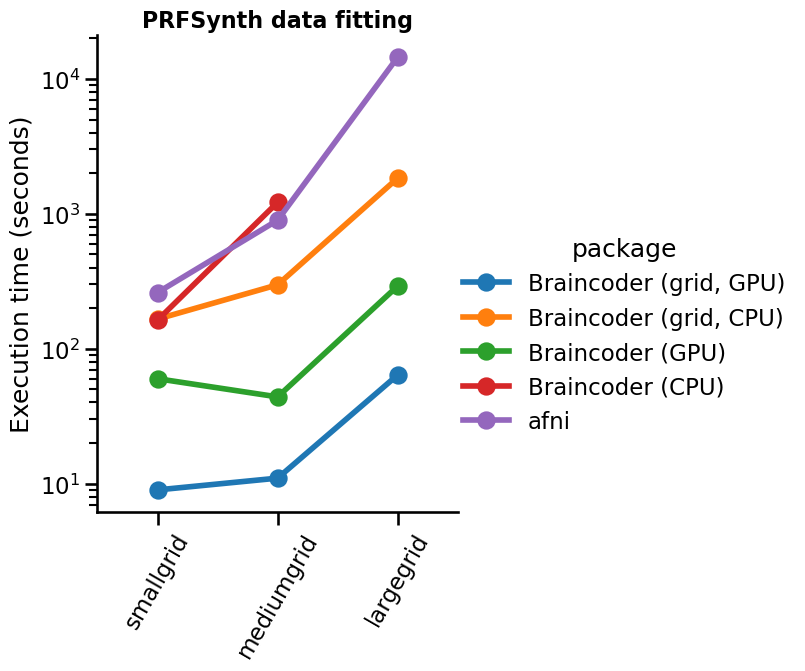

In [3]:
import seaborn as sns
sns.set_context('talk')
sns.catplot(hue='package', x='dataset', y='time', data=results, height=6, aspect=1, kind='point',
            sharey=False, order=['smallgrid', 'mediumgrid', 'largegrid'])

# Give log y-axis
import matplotlib.pyplot as plt
plt.yscale('log')
plt.ylabel('Execution time (seconds)')

plt.title('PRFSynth data fitting', fontdict={'fontweight': 'bold', 'fontsize': 16})

# Turn xticks vertical
plt.xticks(rotation=60)
plt.xlabel(None)

In [39]:
results

,package,dataset,content,time
0,braincoder.grid.gpu,smallgrid,Execution time: 9 seconds\n,9
1,braincoder.grid.cpu,vanes2019,Execution time: 1616 seconds\n,1616
2,braincoder.grid.gpu,vanes2019,Execution time: 85 seconds\n,85
3,braincoder.grid.cpu,smallgrid,Execution time: 166 seconds\n,166
4,braincoder.hrf.gpu,largegrid,Execution time: 292 seconds\n,292
5,braincoder.grid.gpu,largegrid,Execution time: 64 seconds\n,64
6,braincoder.grid.cpu,largegrid,Execution time: 1841 seconds\n,1841
7,braincoder.hrf.gpu,smallgrid,Execution time: 60 seconds\n,60
8,braincoder.grid.cpu,mediumgrid,Execution time: 298 seconds\n,298
9,braincoder.grid.gpu,mediumgrid,Execution time: 11 seconds\n,11
